<IPython.core.display.Latex object>

Statevector([-1.32994552e-17+2.99983477e-17j,
             -5.05814134e-17+2.57136113e-17j,
              7.07106781e-01-1.08244507e-16j,
              5.39487294e-17+1.75841915e-17j,
              2.99983477e-17+1.32994552e-17j,
              1.06509266e-17+2.09515074e-17j,
             -9.52420783e-18-2.16489014e-17j,
             -7.28361059e-18+2.23462954e-17j,
             -1.32994552e-17+2.99983477e-17j,
             -5.05814134e-17+2.57136113e-17j,
              7.07106781e-01-1.51542310e-16j,
              5.39487294e-17+1.75841915e-17j,
              2.99983477e-17+1.32994552e-17j,
              1.06509266e-17+2.09515074e-17j,
             -9.52420783e-18+2.16489014e-17j,
             -7.28361059e-18+2.23462954e-17j],
            dims=(2, 2, 2, 2))


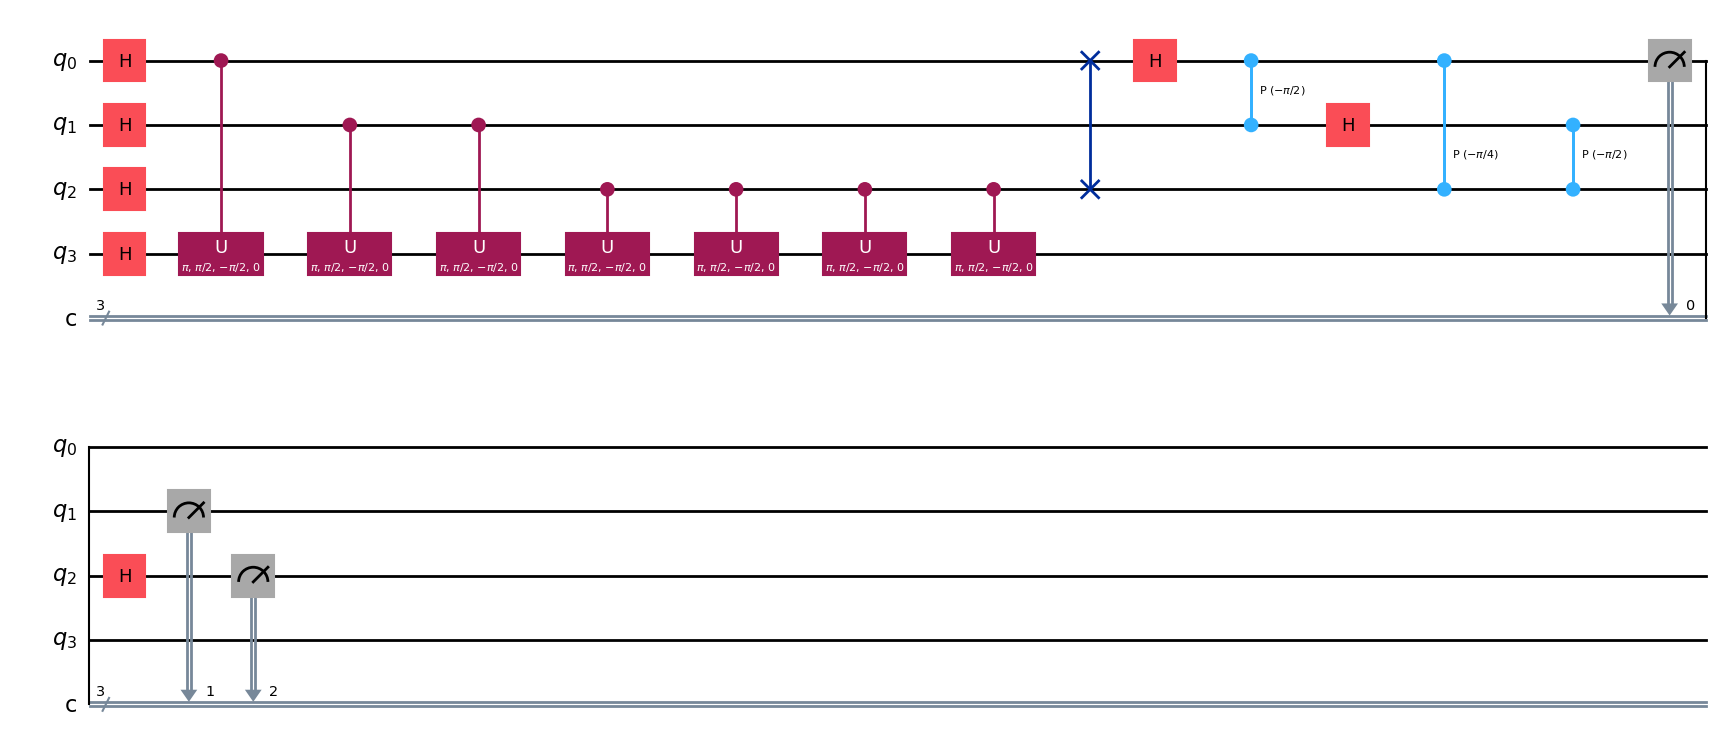

Measurements counts:{'010': 1024}


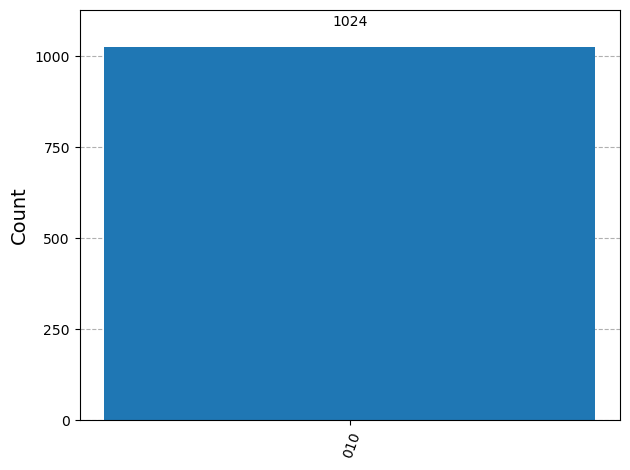

In [11]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import math
from qiskit.quantum_info import Statevector

from qiskit.visualization import array_to_latex
from IPython.display import display

qpe = QuantumCircuit(4, 3)
#qpe.x(3)
qpe.h(3) 


for qubit in range(3):
    qpe.h(qubit)

#Controlled U^2t
for i in range(3):
    for j in range(2**i):
        qpe.cu(math.pi, math.pi/2, -math.pi/2, 0, i, 3)

# Inverse QFT
def qft_dagger(qc, n):
    """n-qubit QFTdagger the first n qubits in circ"""
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-math.pi/float(2**(j-m)), m, j)
        qc.h(j)

        
qft_dagger(qpe, 3)

state=Statevector(qpe)
display(array_to_latex(state.data, prefix="|\\psi\\rangle = "))
print(state)


#measurement
for n in range(3):
    qpe.measure(n,n)

display(qpe.draw('mpl'))

sim = AerSimulator()
result = sim.run([qpe]).result()
counts = result.get_counts(0)
print(f"Measurements counts:{counts}")
plot_histogram(counts)

Result: 010, in number form: 3. Divide by 2^n (n=number of counting qubits), = 3/8., 0.375 approx 1/2. Result: 110, in number form 10, 10/8 = 1.25 approx 3/2.